## analysing the changes in Northward heat transport - atmos and oceanic 

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import numpy as np
import os
import xarray as xr
import xcdat as xc

In [3]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.ticker as mticker
import pandas as pd


In [4]:
import netCDF4
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.util import add_cyclic_point
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

ERROR 1: PROJ: proj_create_from_database: Open of /g/data/xp65/public/./apps/med_conda/envs/analysis3-25.09/share/proj failed


In [5]:
import cmocean
from scipy import stats

In [6]:
mpl.rcParams['font.family'] = 'Droid Sans'
mpl.rcParams['font.size'] = 14
# Edit axes parameters
mpl.rcParams['axes.linewidth'] = 0.8
# Tick properties
mpl.rcParams['xtick.major.size'] = 5
mpl.rcParams['xtick.minor.size'] = 3
mpl.rcParams['xtick.major.width'] = 1
mpl.rcParams['xtick.direction'] = 'out'
mpl.rcParams['ytick.major.size'] = 5
mpl.rcParams['ytick.minor.size'] = 3
mpl.rcParams['ytick.major.width'] = 1
mpl.rcParams['ytick.direction'] = 'out'

In [7]:
def plot_decorator():
    ax = plt.gca()
    
    # Minor ticks
    # ax.minorticks_on()
    # plt.tick_params(which='minor', axis='x', bottom=False)
    
    # Grid (light, behind data)
    ax.grid(color='gray', lw=0.4, alpha=0.1)
    
    # Remove top/right spines (Nature style)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Tight layout
    # plt.tight_layout()

In [8]:
from matplotlib.colors import BoundaryNorm as BM
# from matplotlib.colors import LogNorm as LM
import matplotlib.patches as mpatches

In [9]:
def plot_background(ax, draw_labels=False):
    ax.add_feature(cfeature.COASTLINE, alpha=0.9, lw=1.1)
    # ax.set_global()
    # ax.add_feature(cfeature.LAND, color='lightgray')
    # ax.add_feature(cfeature.OCEAN, color='lightgray')
    gl = ax.gridlines(draw_labels=draw_labels,
                      linewidth=1, color='gray', alpha=0.01, linestyle='--')
    gl.top_labels = False
    # gl.left_labels = False
    # gl.bottom_labels = False
    gl.right_labels = False
    gl.xlines = False
    # gl.xlocator = mticker.FixedLocator([-180, -45, 0, 45, 180])
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlabel_style = {'size': 10, 'color': 'k'}
    gl.ylabel_style = {'size': 10, 'color': 'k'}
    return ax



def add_qk_bbox(ax, qk, q, patch_zorder):
    # --- Add a box around both arrow and label ---
    # Choose size & position in Axes fraction coordinates
    box_x, box_y = 1.03, 1.07   # lower-left corner of box
    box_w, box_h = 0.14, 0.05    # width & height of box

    rect = mpatches.FancyBboxPatch(
        (box_x, box_y), box_w, box_h,
        transform=ax.transAxes,
        boxstyle="square,pad=0.25",
        facecolor='white', edgecolor='black', alpha=1.0,
        zorder=patch_zorder, clip_on=True  # below text & arrow
    )
    ax.add_patch(rect)

    # Raise the quiverkey elements above the box
    qk.text.set_zorder(4)
    q.set_zorder(2)


def plot_maps(x, y, z, titles, labels, cmap, levels, pval = [], draw_winds=False, u_wnd=[], v_wnd=[], wind_scale=20, draw_contour=False, contour_data=[], contour_levels=[], contour_colors='gray', 
            nrows=1, ncols=3, figsize=(12,4), land_mask_list = [0], add_patch=False, add_patch_extra=False, hatch_type = 'insig', proj=ccrs.Robinson(central_longitude=160), 
            cbar_kwargs=dict(orientation='vertical', label='Precip', aspect=40, shrink=0.7, pad=0.05), draw_labels=False, draw_colorbar=True, auto_aspect=False):

    fig, axarr = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize, constrained_layout=False, subplot_kw={'projection':proj})
    
    axlist = axarr.flatten()
    
    for ax in axlist:
        if draw_labels:
            plot_background(ax, draw_labels)
        else:
            plot_background(ax)
        if auto_aspect:
            ax.set_aspect('auto')
        else:
            continue
    
    for i in range(len(z)):
        axlist[i].contourf(x, y, z[i], cmap = cmap, transform = ccrs.PlateCarree(central_longitude=0), levels=levels, extend='both')
        if draw_winds:
            # step = max(1, x.shape[0] // 2)
            step = 6
            # q = axlist[i].quiver(x[::step, ::step], y[::step, ::step], u_wnd[i][::step, ::step], v_wnd[i][::step, ::step], scale=wind_scale, color='k', pivot='middle', transform=ccrs.PlateCarree())
            q = axlist[i].quiver(x[::step, ::step], y[::step, ::step], u_wnd[i][::step, ::step], v_wnd[i][::step, ::step], scale_units='xy', scale=wind_scale, width=0.003, headwidth=3, headlength=4, headaxislength=3, color='k', pivot='middle', transform=ccrs.PlateCarree())
            if i == 0:
                qk = ax.quiverkey(q, X=0.85, Y=0.9, U=1.0, label='1 m/s', labelpos='E', coordinates='axes')
                add_qk_bbox(axlist[i], qk, q, patch_zorder=4)
            # qk.text.set_bbox(dict(facecolor='white', edgecolor='k', boxstyle='square,pad=0.3'))

        if draw_contour:
            axlist[i].contour(x, y, contour_data[i], cmap = None, levels=contour_levels, colors=contour_colors, transform = ccrs.PlateCarree(central_longitude=0), alpha=0.5)
        if i in land_mask_list:
            axlist[i].add_feature(cfeature.LAND, color = 'k', zorder=1)
        if pval != []:
            if hatch_type == 'insig':
                pval_plot = np.ma.masked_less_equal(pval[i], 0.05)
                axlist[i].pcolor(x, y, pval_plot, alpha = 0., hatch='...', transform = ccrs.PlateCarree(central_longitude=0))
            elif hatch_type == 'sig':
                pval_plot = np.ma.masked_greater(pval[i], 0.05)
                axlist[i].pcolor(x, y, pval_plot, alpha = 0., hatch='...', transform = ccrs.PlateCarree(central_longitude=0))
        axlist[i].set_title(titles[i], fontdict={'fontsize':14})
        axlist[i].text(0.1, 1.05, labels[i], size=16, fontweight='bold', transform=axlist[i].transAxes)
        if add_patch:
            # axlist[i].add_patch(mpatches.Rectangle(xy=[120, -65], width=170, height=20,
            #                                 facecolor='none', edgecolor='k',
            #                                 transform=ccrs.PlateCarree()))
            axlist[i].add_patch(mpatches.Rectangle(xy=[190, -5], width=80, height=10,
                                            facecolor='none', edgecolor='k',
                                            transform=ccrs.PlateCarree()))
            axlist[i].add_patch(mpatches.Rectangle(xy=[140, -5], width=30, height=10,
                                            facecolor='none', edgecolor='k',
                                            transform=ccrs.PlateCarree()))
            # axlist[i].add_patch(mpatches.Rectangle(xy=[250, -30], width=40, height=20,
            #                                 facecolor='none', edgecolor='k',
            #                                 transform=ccrs.PlateCarree()))
            # axlist[i].add_patch(mpatches.Rectangle(xy=[140, 60], width=150, height=20,
            #                                             facecolor='none', edgecolor='tab:green', lw=1.5,
            #                                             transform=ccrs.PlateCarree()))
            # axlist[i].add_patch(mpatches.Rectangle(xy=[140, -80], width=150, height=20,
            #                                             facecolor='none', edgecolor='tab:green', lw=1.5,
            #                                             transform=ccrs.PlateCarree()))
        if add_patch_extra:
            axlist[i].add_patch(mpatches.Rectangle(xy=[190, 20], width=60, height=20,
                                                        facecolor='none', edgecolor='k', lw=1.5,
                                                        transform=ccrs.PlateCarree()))
            axlist[i].add_patch(mpatches.Rectangle(xy=[210, -40], width=60, height=30,
                                                        facecolor='none', edgecolor='k', lw=1.5,
                                                        transform=ccrs.PlateCarree()))
                    
    if draw_colorbar:
        norm = BM(levels, 256, extend='both')
        fig.colorbar(mpl.cm.ScalarMappable(norm = norm, cmap=cmap), ax = axlist, \
                    orientation = cbar_kwargs['orientation'], shrink=cbar_kwargs['shrink'], aspect = cbar_kwargs['aspect'], pad = cbar_kwargs['pad'], label = cbar_kwargs['label'], ticks=levels[::2])



def plot_single_map(x, y, z, title, label, cmap, levels, pval = [], draw_winds=False, u_wnd=[], v_wnd=[], wind_scale=20, draw_contour=False, contour_data=[], contour_levels=[], contour_colors='gray', 
                figsize=(12,4), land_mask_list = False, add_patch=False, add_patch_extra=False, hatch_type = 'insig', proj=ccrs.Robinson(central_longitude=160), 
                cbar_kwargs=dict(orientation='vertical', label='Precip', aspect=40, shrink=0.7, pad=0.05), draw_labels=False, draw_colorbar=True, auto_aspect=False):

    ax = plt.axes(projection=proj)
    if draw_labels:
        plot_background(ax, draw_labels)
    else:
        plot_background(ax)
    if auto_aspect:
        ax.set_aspect('auto')
    
    cf=ax.contourf(x, y, z, cmap = cmap, transform = ccrs.PlateCarree(central_longitude=0), levels=levels, extend='both')
    if draw_winds:
        wind_separation = 6
        q = ax.quiver(x[::wind_separation, ::wind_separation], y[::wind_separation, ::wind_separation], u_wnd.to_numpy()[::wind_separation, ::wind_separation], v_wnd.to_numpy()[::wind_separation, ::wind_separation], scale=wind_scale, \
        color='k', transform=ccrs.PlateCarree())
        qk = ax.quiverkey(q, X=0.85, Y=0.9, U=1.0, label='1 m/s', labelpos='E', coordinates='axes')
        # qk.text.set_bbox(dict(facecolor='white', edgecolor='k'))#, boxstyle='round,pad=0.3'))

        plt.tight_layout()
        plt.show()
    if draw_contour:
        ax.contour(x, y, contour_data, cmap = None, levels=contour_levels, colors=contour_colors, transform = ccrs.PlateCarree(central_longitude=0), alpha=0.5)
    if land_mask_list:
        ax.add_feature(cfeature.LAND, color = 'k', zorder=1)
    if pval != []:
        if hatch_type == 'insig':
            pval_plot = np.ma.masked_less_equal(pval, 0.05)
            ax.pcolor(x, y, pval_plot, alpha = 0., hatch='...', transform = ccrs.PlateCarree(central_longitude=0))
        elif hatch_type == 'sig':
            pval_plot = np.ma.masked_greater(pval, 0.05)
            ax.pcolor(x, y, pval_plot, alpha = 0., hatch='...', transform = ccrs.PlateCarree(central_longitude=0))
    ax.set_title(title, fontdict={'fontsize':14})
    ax.text(0.1, 1.05, label, size=16, fontweight='bold', transform=ax.transAxes)
    if add_patch:
        ax.add_patch(mpatches.Rectangle(xy=[190, -5], width=80, height=10,
                                        facecolor='none', edgecolor='k',
                                        transform=ccrs.PlateCarree()))
        ax.add_patch(mpatches.Rectangle(xy=[140, -5], width=30, height=10,
                                        facecolor='none', edgecolor='k',
                                        transform=ccrs.PlateCarree()))
    
    if add_patch_extra:
        ax.add_patch(mpatches.Rectangle(xy=[190, 20], width=60, height=20,
                                                    facecolor='none', edgecolor='k', lw=1.5,
                                                    transform=ccrs.PlateCarree()))
        ax.add_patch(mpatches.Rectangle(xy=[210, -40], width=60, height=30,
                                                    facecolor='none', edgecolor='k', lw=1.5,
                                                    transform=ccrs.PlateCarree()))
                    
    if draw_colorbar:
        norm = BM(levels, 256, extend='both')
        plt.colorbar(mpl.cm.ScalarMappable(norm = norm, cmap=cmap), ax = ax, \
                    orientation = cbar_kwargs['orientation'], shrink=cbar_kwargs['shrink'], aspect = cbar_kwargs['aspect'], pad = cbar_kwargs['pad'], label = cbar_kwargs['label'], ticks=levels[::2])

In [10]:
from functions import preproc_funcs as funcs

In [11]:
from functions import xr_lowess

### import data

In [12]:
rsdt_trans = xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/lens_40_member/ACCESS-ESM1-5_ssp5_rsdt.nc').rsdt.load()
rsut_trans = xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/lens_40_member/ACCESS-ESM1-5_ssp5_rsut.nc').rsut.load()
rlut_trans = xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/lens_40_member/ACCESS-ESM1-5_ssp5_rlut.nc').rlut.load()

In [13]:
rsds_trans = xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/lens_40_member/ACCESS-ESM1-5_ssp5_rsds.nc').rsds.load()
rsus_trans = xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/lens_40_member/ACCESS-ESM1-5_ssp5_rsus.nc').rsus.load()
rlds_trans = xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/lens_40_member/ACCESS-ESM1-5_ssp5_rlds.nc').rlds.load()
rlus_trans = xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/lens_40_member/ACCESS-ESM1-5_ssp5_rlus.nc').rlus.load()

In [1]:
hfss_trans = xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/lens_40_member/ACCESS-ESM1-5_ssp5_hfss.nc').hfss.load()
hfls_trans = xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/lens_40_member/ACCESS-ESM1-5_ssp5_hfls.nc').hfls.load()

NameError: name 'xr' is not defined

In [ ]:
rsdt_stable = xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/access_stable/access_stable_rsdt.nc').rsdt.load()
rsut_stable = xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/access_stable/access_stable_rsut.nc').rsut.load()
rlut_stable = xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/access_stable/access_stable_rlut.nc').rlut.load()

In [15]:
rsds_stable = xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/access_stable/access_stable_rsds.nc').rsds.load()
rsus_stable = xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/access_stable/access_stable_rsus.nc').rsus.load()
rlds_stable = xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/access_stable/access_stable_rlds.nc').rlds.load()
rlus_stable = xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/access_stable/access_stable_rlus.nc').rlus.load()

In [31]:
hfss_stable = xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/access_stable/access_stable_hfss.nc').hfss.load()
hfls_stable = xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/access_stable/access_stable_hfls.nc').hfls.load()

In [32]:
basin_mask = xc.open_dataset('/g/data/fs38/publications/CMIP6/CMIP/CSIRO/ACCESS-ESM1-5/historical/r10i1p1f1/Ofx/basin/gn/latest/basin_Ofx_ACCESS-ESM1-5_historical_r10i1p1f1_gn.nc')
basin_mask

2025-10-27 21:24:27,651 [WARNING]: dataset.py(open_dataset:121) >> "No time coordinates were found in this dataset to decode. If time coordinates were expected to exist, make sure they are detectable by setting the CF 'axis' or 'standard_name' attribute (e.g., ds['time'].attrs['axis'] = 'T' or ds['time'].attrs['standard_name'] = 'time'). Afterwards, try decoding again with `xcdat.decode_time`."
2025-10-27 21:24:27,651 [WARNING]: dataset.py(open_dataset:121) >> "No time coordinates were found in this dataset to decode. If time coordinates were expected to exist, make sure they are detectable by setting the CF 'axis' or 'standard_name' attribute (e.g., ds['time'].attrs['axis'] = 'T' or ds['time'].attrs['standard_name'] = 'time'). Afterwards, try decoding again with `xcdat.decode_time`."
2025-10-27 21:24:27,666 [WARNING]: bounds.py(add_missing_bounds:191) >> The j coord variable has a 'units' attribute that is not in degrees.
2025-10-27 21:24:27,666 [WARNING]: bounds.py(add_missing_bounds

<xarray.Dataset> Size: 10MB
Dimensions:             (j: 300, i: 360, vertices: 4, bnds: 2)
Coordinates:
  * j                   (j) int32 1kB 0 1 2 3 4 5 6 ... 294 295 296 297 298 299
  * i                   (i) int32 1kB 0 1 2 3 4 5 6 ... 354 355 356 357 358 359
    latitude            (j, i) float64 864kB -77.88 -77.88 ... 65.63 65.21
    longitude           (j, i) float64 864kB 80.5 81.5 82.5 ... 79.97 79.99
Dimensions without coordinates: vertices, bnds
Data variables:
    vertices_latitude   (j, i, vertices) float64 3MB ...
    vertices_longitude  (j, i, vertices) float64 3MB ...
    basin               (j, i) float64 864kB ...
    i_bnds              (i, bnds) float64 6kB -0.5 0.5 0.5 ... 358.5 358.5 359.5
Attributes: (12/47)
    Conventions:            CF-1.7 CMIP-6.2
    activity_id:            CMIP
    branch_method:          standard
    branch_time_in_child:   0.0
    branch_time_in_parent:  87658.0
    creation_date:          2020-06-05T04:50:43Z
    ...                     ...
    tracking_id:            hdl:21.14100/13699ec4-baf3-415d-a4c7-8b6d820b233d
    variable_id:            basin
    variant_label:          r10i1p1f1
    version:                v20200605
    license:                CMIP6 model data produced by CSIRO is licensed un...
    cmor_version:           3.4.0

In [33]:
import xesmf as xe
ds_out = xe.util.cf_grid_2d(-0.75, 360, 1.5, -90, 90, 1.5)
ds_out

<xarray.Dataset> Size: 9kB
Dimensions:             (lon: 240, bound: 2, lat: 120)
Coordinates:
  * lon                 (lon) float64 2kB 0.0 1.5 3.0 4.5 ... 355.5 357.0 358.5
  * lat                 (lat) float64 960B -89.25 -87.75 -86.25 ... 87.75 89.25
    latitude_longitude  float64 8B nan
Dimensions without coordinates: bound
Data variables:
    lon_bounds          (lon, bound) float64 4kB -0.75 0.75 0.75 ... 357.8 359.2
    lat_bounds          (lat, bound) float64 2kB -90.0 -88.5 -88.5 ... 88.5 90.0

In [34]:
regridder = xe.Regridder(basin_mask, ds_out, 'nearest_s2d', periodic=True, ignore_degenerate=True)

In [35]:
basin_mask_regrid = regridder(basin_mask).basin

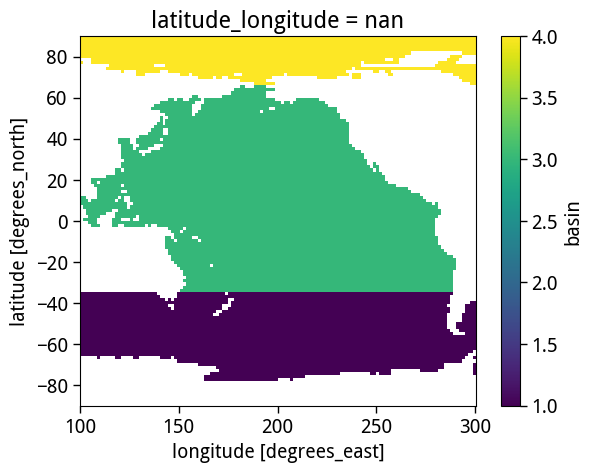

In [36]:
basin_mask_indo_pacific_so_pacific = basin_mask_regrid.where(basin_mask_regrid.isin([1,3,4]))
basin_mask_indo_pacific_so_pacific.sel(lon = slice(100, 300)).plot()

In [37]:
def calc_aht_dry_moist_surface_proxy(
    rsdt, rsut, rlut, 
    rsds, rsus, rlds, rlus, 
    hfss, hfls, basin_mask, lon_min=100, lon_max=300):
    
    a = 6.371e6  # Earth radius in meters

    # Compute net TOA radiation (downward positive)
    r_toa = ((rsdt - rsut - rlut).where(basin_mask)).sel(lon = slice(lon_min, lon_max))  # W/m^2

    # Compute net surface radiative flux (downward positive)
    r_sfc = ((rsds - rsus) + (rlds - rlus)).sel(lon = slice(lon_min, lon_max))

    # Sensible heat flux (upward positive), so invert sign to downward positive for energy budget
    shf = ((-hfss).where(basin_mask)).sel(lon = slice(lon_min, lon_max))  # W/m^2

    # Latent heat flux (upward positive), invert sign similarly
    lhf = ((-hfls).where(basin_mask)).sel(lon = slice(lon_min, lon_max))  # W/m^2

    # Net surface flux to atmosphere (positive downward)
    f_sfc = (r_sfc + shf + lhf).where(basin_mask)

    # Column net atmospheric radiative heating (downward positive)
    q_atm = r_toa - f_sfc  # W/m^2

    # Total AHT: integrate net atmospheric column heating in meridional direction
    qz = q_atm.mean(dim='lon', skipna=True)
    lat_rad = np.deg2rad(qz.lat)
    coslat = np.cos(lat_rad)
    dphi = np.gradient(lat_rad)
    integrand_total = qz * coslat
    aht_total = 2 * np.pi * a**2 * (integrand_total * dphi).cumsum(dim='lat')
    aht_total_pw = aht_total / 1e15

    # Dry component proxy: net sensible heat flux (shf) term integrated similarly
    shf_z = shf.mean(dim='lon', skipna=True)
    integrand_dry = shf_z * coslat
    aht_dry = 2 * np.pi * a**2 * (integrand_dry * dphi).cumsum(dim='lat')
    aht_dry_pw = aht_dry / 1e15

    # Moist component proxy: net latent heat flux (lhf) term integrated similarly
    lhf_z = lhf.mean(dim='lon', skipna=True)
    integrand_moist = lhf_z * coslat
    aht_moist = 2 * np.pi * a**2 * (integrand_moist * dphi).cumsum(dim='lat')
    aht_moist_pw = aht_moist / 1e15

    return aht_total_pw, aht_dry_pw, aht_moist_pw



def toa_fscf_calc(
    rsdt, rsut, rlut, 
    rsds, rsus, rlds, rlus, 
    hfss, hfls, basin_mask, lon_min=0, lon_max=360):
    # Compute net TOA radiation (downward positive)
    r_toa = ((rsdt - rsut - rlut).where(basin_mask)).sel(lon = slice(lon_min, lon_max))  # W/m^2

    # Compute net surface radiative flux (downward positive)
    r_sfc = ((rsds - rsus) + (rlds - rlus)).sel(lon = slice(lon_min, lon_max))

    # Sensible heat flux (upward positive), so invert sign to downward positive for energy budget
    shf = ((-hfss).where(basin_mask)).sel(lon = slice(lon_min, lon_max))  # W/m^2

    # Latent heat flux (upward positive), invert sign similarly
    lhf = ((-hfls).where(basin_mask)).sel(lon = slice(lon_min, lon_max))  # W/m^2

    # Net surface flux to atmosphere (positive downward)
    f_sfc = (r_sfc + shf + lhf).where(basin_mask)
    return r_toa, f_sfc

In [ ]:
aht_trans, aht_dry_trans, aht_moist_trans = calc_aht_dry_moist_surface_proxy(rsdt_trans, rsut_trans, rlut_trans, rsds_trans, rsus_trans, rlds_trans, rlus_trans, hfss_trans, hfls_trans, basin_mask=basin_mask_indo_pacific_so_pacific.isin([1,3,4]))
print('done')
rtoa_trans, fsfc_trans = toa_fscf_calc(rsdt_trans, rsut_trans, rlut_trans, rsds_trans, rsus_trans, rlds_trans, rlus_trans, hfss_trans, hfls_trans, basin_mask=basin_mask_indo_pacific_so_pacific)
print('done')

In [ ]:
aht_stable, aht_dry_stable, aht_moist_stable = calc_aht_dry_moist_surface_proxy(rsdt_stable, rsut_stable, rlut_stable, rsds_stable, rsus_stable, rlds_stable, rlus_stable, hfss_stable, hfls_stable, basin_mask=basin_mask_indo_pacific_so_pacific.isin([1,3,4]))
print('done')
rtoa_stable, fsfc_stable = toa_fscf_calc(rsdt_stable, rsut_stable, rlut_stable, rsds_stable, rsus_stable, rlds_stable, rlus_stable, hfss_stable, hfls_stable, basin_mask=basin_mask_indo_pacific_so_pacific)
print('done')

done
done


In [12]:
htovovrt_trans_orig = xr.open_mfdataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/lens_40_member/ACCESS-ESM1-5_ssp5_htovovrt_original.nc').htovovrt.load()
htovgyre_trans_orig = xr.open_mfdataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/lens_40_member/ACCESS-ESM1-5_ssp5_htovgyre_original.nc').htovgyre.load()

In [13]:
htovovrt_stable_orig = xr.open_mfdataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/access_stable/access_stable_htovovrt.nc').htovovrt.load()
htovgyre_stable_orig = xr.open_mfdataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/access_stable/access_stable_htovgyre.nc').htovgyre.load()

In [ ]:
aht_pi = aht_trans.sel(time = slice('1850', '1900')).mean('time')
aht_trans_2060 = aht_trans.sel(time = slice('2045', '2075')).mean('time')
aht_trans_2045 = aht_trans.sel(time = slice('2030', '2060')).mean('time')
aht_trans_2030 = aht_trans.sel(time = slice('2015', '2045')).mean('time')

In [14]:
htovovrt_pi = htovovrt_trans_orig.isel(basin=1).sel(time = slice('1850', '1900')).mean('time')
htovovrt_trans_2060 = htovovrt_trans_orig.isel(basin=1).sel(time = slice('2045', '2075')).mean('time')
htovovrt_trans_2045 = htovovrt_trans_orig.isel(basin=1).sel(time = slice('2030', '2060')).mean('time')
htovovrt_trans_2030 = htovovrt_trans_orig.isel(basin=1).sel(time = slice('2015', '2045')).mean('time')

In [15]:
htovgyre_pi = htovgyre_trans_orig.isel(basin=1).sel(time = slice('1850', '1900')).mean('time')
htovgyre_trans_2060 = htovgyre_trans_orig.isel(basin=1).sel(time = slice('2045', '2075')).mean('time')
htovgyre_trans_2045 = htovgyre_trans_orig.isel(basin=1).sel(time = slice('2030', '2060')).mean('time')
htovgyre_trans_2030 = htovgyre_trans_orig.isel(basin=1).sel(time = slice('2015', '2045')).mean('time')

In [16]:
oht_pi = htovgyre_pi + htovovrt_pi

oht_trans_2030 = htovgyre_trans_2030 + htovovrt_trans_2030
oht_trans_2045 = htovgyre_trans_2045 + htovovrt_trans_2045
oht_trans_2060 = htovgyre_trans_2060 + htovovrt_trans_2060

In [ ]:
nht_pi = oht_pi + aht_pi

nht_trans_2030 = oht_trans_2030 + aht_trans_2030
nht_trans_2045 = oht_trans_2045 + aht_trans_2045
nht_trans_2060 = oht_trans_2060 + aht_trans_2060

In [17]:
def additional_sampling_stabilisation(da, initiator=100, spacer=30):
    i = initiator
    da_list = []
    while i <= 1000 - spacer:
        sample_da = da.isel(time = slice(i,i+spacer)).mean('time')
        da_list.append(sample_da)
        i += spacer
    print('Done')
    out_da = xr.concat(da_list, dim=np.arange(0, (1000 - initiator)/spacer, 1))
    if 'model' in out_da.coords:
        return out_da.drop('model').rename(dict(concat_dim='model'))
    else:
        return out_da.rename(dict(concat_dim='model'))


def additional_sampling_stabilisation_nomeans(da, initiator=100, spacer=30):
    i = initiator
    da_list = []
    while i <= 1000 - spacer:
        sample_da = da.isel(time = slice(i,i+spacer))
        da_list.append(sample_da)
        i += spacer
    print('Done')
    out_da = xr.concat(da_list, dim=np.arange(0, (1000 - initiator)/spacer, 1))
    if 'model' in out_da.coords:
        return out_da.drop('model').rename(dict(concat_dim='model'))
    else:
        return out_da.rename(dict(concat_dim='model'))


In [ ]:
aht_stable_2030 = additional_sampling_stabilisation(xr.where(aht_stable != 0, aht_stable, np.nan).sel(model = '2030'))
aht_stable_2045 = additional_sampling_stabilisation(xr.where(aht_stable != 0, aht_stable, np.nan).sel(model = '2045'))
aht_stable_2060 = additional_sampling_stabilisation(xr.where(aht_stable != 0, aht_stable, np.nan).sel(model = '2060'))

Done
Done
Done


In [18]:
htovovrt_stable_2030 = additional_sampling_stabilisation(htovovrt_stable_orig.isel(basin=1).sel(model = '2030'))
htovovrt_stable_2045 = additional_sampling_stabilisation(htovovrt_stable_orig.isel(basin=1).sel(model = '2045'))
htovovrt_stable_2060 = additional_sampling_stabilisation(htovovrt_stable_orig.isel(basin=1).sel(model = '2060'))

Done
Done
Done


In [19]:
htovgyre_stable_2030 = additional_sampling_stabilisation(htovgyre_stable_orig.isel(basin=1).sel(model = '2030'))
htovgyre_stable_2045 = additional_sampling_stabilisation(htovgyre_stable_orig.isel(basin=1).sel(model = '2045'))
htovgyre_stable_2060 = additional_sampling_stabilisation(htovgyre_stable_orig.isel(basin=1).sel(model = '2060'))

Done
Done
Done


In [20]:
oht_stable_2030 = htovgyre_stable_2030 + htovovrt_stable_2030
oht_stable_2045 = htovgyre_stable_2045 + htovovrt_stable_2045
oht_stable_2060 = htovgyre_stable_2060 + htovovrt_stable_2060

In [ ]:

nht_stable_2030 = oht_stable_2030 + aht_stable_2030
nht_stable_2045 = oht_stable_2045 + aht_stable_2045
nht_stable_2060 = oht_stable_2060 + aht_stable_2060

In [21]:
import seaborn as sns

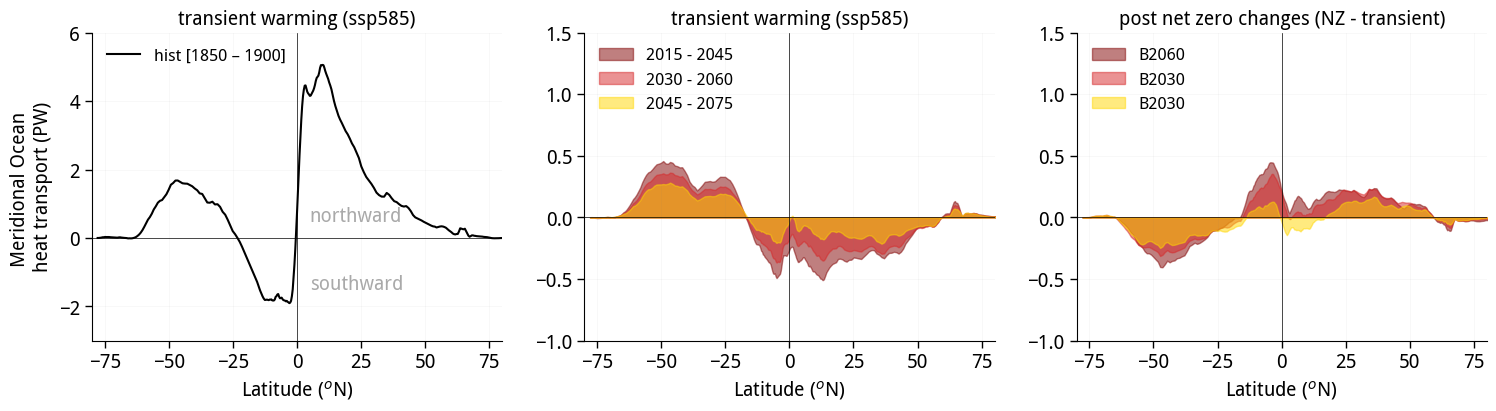

In [24]:
plt.figure(figsize=(18,4))

plt.subplot(131)
xdata = htovovrt_pi.lat.to_numpy()

plt.plot(xdata, htovovrt_pi.quantile(0.5, 'model')/1e15, color='k', label='hist [1850 – 1900]')

plt.ylabel('Meridional Ocean \nheat transport (PW)')
plt.xlabel('Latitude ($^{o}$N)')
# plot_decorator()
plt.axhline(0.0, lw=0.5, color='k')
plt.axvline(0.0, lw=0.5, color='k')
# plt.axvline(-30.0, lw=0.5, color='k', ls='--', alpha=0.2)
# plt.axvline(30.0, lw=0.5, color='k', ls='--', alpha=0.2)
# sns.despine(left=True, right=True)
# plt.grid(alpha=0.05)
plot_decorator()
plt.xlim(-80, 80)
plt.ylim(-3, 6)
plt.text(5, 0.5, 'northward', size=14, color='darkgray')
plt.text(5, -1.5, 'southward', size=14, color='darkgray')
plt.title('transient warming (ssp585)', fontsize=14)
plt.legend(frameon=False, loc='upper left', fontsize=12)


plt.subplot(132)
xdata = htovovrt_pi.lat.to_numpy()

# plt.fill_between(xdata, htovovrt_pi.quantile(0.1, 'model')/1e15, htovovrt_pi.quantile(0.9, 'model')/1e15, color='k', alpha=0.2)

# plt.plot(xdata, htovovrt_trans_2030.quantile(0.5, 'model')/1e15, color='gold')
# plt.fill_between(xdata, htovovrt_trans_2030.quantile(0.1, 'model')/1e15, htovovrt_trans_2030.quantile(0.9, 'model')/1e15, color='gold', alpha=0.2)

# plt.plot(xdata, htovovrt_trans_2045.quantile(0.5, 'model')/1e15, color='tab:red')

# plt.plot(xdata, htovovrt_trans_2060.quantile(0.5, 'model')/1e15, color='maroon')

plt.fill_between(xdata, 0, (htovovrt_trans_2060.quantile(0.5, 'model') - htovovrt_pi.quantile(0.5, 'model'))/1e15, color='maroon', alpha=0.5, label='2015 - 2045')
plt.fill_between(xdata, 0, (htovovrt_trans_2045.quantile(0.5, 'model') - htovovrt_pi.quantile(0.5, 'model'))/1e15, color='tab:red', alpha=0.5, label='2030 - 2060')
plt.fill_between(xdata, 0, (htovovrt_trans_2030.quantile(0.5, 'model') - htovovrt_pi.quantile(0.5, 'model'))/1e15, color='gold', alpha=0.5, label='2045 - 2075')


# plt.ylabel('Meridional Ocean \nheat transport (PW)')
plt.xlabel('Latitude ($^{o}$N)')
# plot_decorator()
plt.axhline(0.0, lw=0.5, color='k')
plt.axvline(0.0, lw=0.5, color='k')
# plt.axvline(-30.0, lw=0.5, color='k', ls='--', alpha=0.2)
# plt.axvline(30.0, lw=0.5, color='k', ls='--', alpha=0.2)
# sns.despine(left=True, right=True)
# plt.grid(alpha=0.05)
plot_decorator()
plt.xlim(-80, 80)
plt.ylim(-1.0, 1.5)
# plt.text(5, 0.5, 'northward', size=14, color='darkgray')
# plt.text(5, -1.5, 'southward', size=14, color='darkgray')
plt.title('transient warming (ssp585)', fontsize=14)
plt.legend(frameon=False, loc='upper left', fontsize=12)


# ###
# plt.subplot(132)
# xdata = htovovrt_pi.lat.to_numpy()

# plt.plot(xdata, htovovrt_pi.quantile(0.5, 'model')/1e15, color='k', label='hist [1850 – 1900]')
# # plt.fill_between(xdata, htovovrt_pi.quantile(0.1, 'model')/1e15, htovovrt_pi.quantile(0.9, 'model')/1e15, color='k', alpha=0.2)

# # plt.plot(xdata, htovovrt_stable_2030.quantile(0.5, 'model')/1e15, color='gold')
# # plt.fill_between(xdata, htovovrt_stable_2030.quantile(0.1, 'model')/1e15, htovovrt_stable_2030.quantile(0.9, 'model')/1e15, color='gold', alpha=0.2)

# # plt.plot(xdata, htovovrt_stable_2045.quantile(0.5, 'model')/1e15, color='tab:red')

# # plt.plot(xdata, htovovrt_stable_2060.quantile(0.5, 'model')/1e15, color='maroon')

# plt.fill_between(xdata, 0, (htovovrt_stable_2060.quantile(0.5, 'model') - htovovrt_pi.quantile(0.5, 'model'))/1e15, color='maroon', alpha=0.5, label='NZ $\Delta$ [B2060]')
# plt.fill_between(xdata, 0, (htovovrt_stable_2045.quantile(0.5, 'model') - htovovrt_pi.quantile(0.5, 'model'))/1e15, color='tab:red', alpha=0.5, label='NZ $\Delta$ [B2045]')
# plt.fill_between(xdata, 0, (htovovrt_stable_2030.quantile(0.5, 'model') - htovovrt_pi.quantile(0.5, 'model'))/1e15, color='gold', alpha=0.5, label='NZ $\Delta$ [B2030]')


# # plt.ylabel('Meridional Ocean \nheat transport (PW)')
# plt.xlabel('Latitude ($^{o}$N)')
# # plot_decorator()
# plt.axhline(0.0, lw=0.5, color='k')
# plt.axvline(0.0, lw=0.5, color='k')
# # sns.despine(left=True, right=True)
# # plt.grid(alpha=0.05)
# plot_decorator()
# plt.xlim(-80, 80)
# plt.ylim(-3, 6)
# plt.text(5, 0.5, 'northward', size=14, color='darkgray')
# plt.text(5, -1.5, 'southward', size=14, color='darkgray')
# plt.title('net zero (NZ)', fontsize=14)
# plt.legend(frameon=False, loc='upper left', fontsize=12)


###
plt.subplot(133)
xdata = htovovrt_pi.lat.to_numpy()

# plt.fill_between(xdata, htovovrt_pi.quantile(0.1, 'model')/1e15, htovovrt_pi.quantile(0.9, 'model')/1e15, color='k', alpha=0.2)

# plt.plot(xdata, htovovrt_stable_2030.quantile(0.5, 'model')/1e15, color='gold')
# plt.fill_between(xdata, htovovrt_stable_2030.quantile(0.1, 'model')/1e15, htovovrt_stable_2030.quantile(0.9, 'model')/1e15, color='gold', alpha=0.2)

# plt.plot(xdata, htovovrt_stable_2045.quantile(0.5, 'model')/1e15, color='tab:red')

# plt.plot(xdata, htovovrt_stable_2060.quantile(0.5, 'model')/1e15, color='maroon')

plt.fill_between(xdata, 0, (htovovrt_stable_2060.quantile(0.5, 'model') - htovovrt_trans_2060.quantile(0.5, 'model'))/1e15, color='maroon', alpha=0.5, label='B2060')
plt.fill_between(xdata, 0, (htovovrt_stable_2045.quantile(0.5, 'model') - htovovrt_trans_2045.quantile(0.5, 'model'))/1e15, color='tab:red', alpha=0.5, label='B2030')
plt.fill_between(xdata, 0, (htovovrt_stable_2030.quantile(0.5, 'model') - htovovrt_trans_2030.quantile(0.5, 'model'))/1e15, color='gold', alpha=0.5, label='B2030')


# plt.ylabel('Meridional Ocean \nheat transport (PW)')
plt.xlabel('Latitude ($^{o}$N)')
# plot_decorator()
plt.axhline(0.0, lw=0.5, color='k')
plt.axvline(0.0, lw=0.5, color='k')
# sns.despine(left=True, right=True)
# plt.grid(alpha=0.05)
plot_decorator()
plt.xlim(-80, 80)
plt.ylim(-1.0, 1.5)
# plt.text(5, 0.5, 'northward', size=14, color='darkgray')
# plt.text(5, -1.0, 'southward', size=14, color='darkgray')
plt.title('post net zero changes (NZ - transient)', fontsize=14)
plt.legend(frameon=False, loc='upper left', fontsize=12)

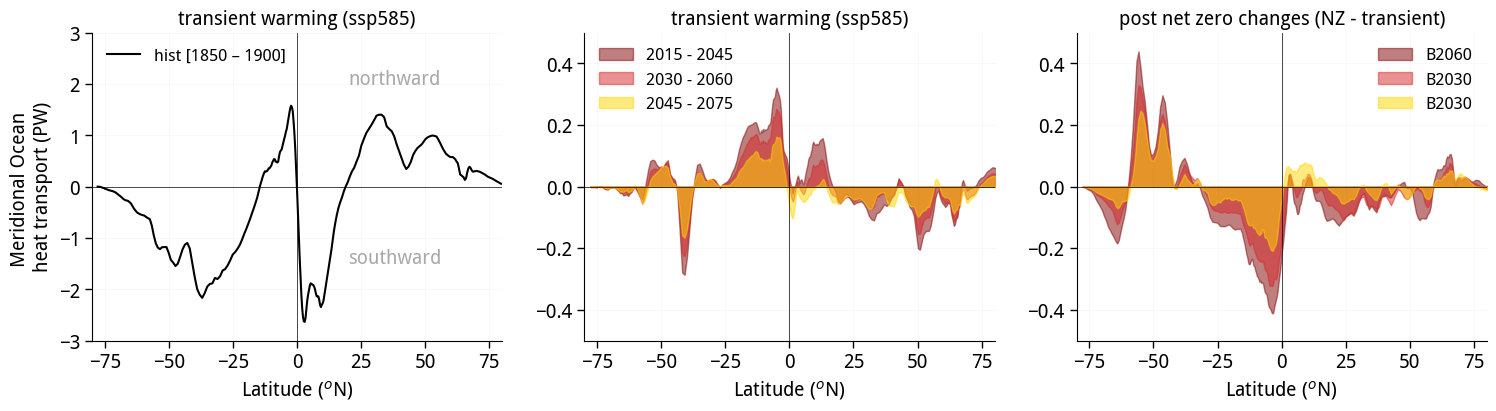

In [28]:
plt.figure(figsize=(18,4))

plt.subplot(131)
xdata = htovgyre_pi.lat.to_numpy()

plt.plot(xdata, htovgyre_pi.quantile(0.5, 'model')/1e15, color='k', label='hist [1850 – 1900]')

plt.ylabel('Meridional Ocean \nheat transport (PW)')
plt.xlabel('Latitude ($^{o}$N)')
# plot_decorator()
plt.axhline(0.0, lw=0.5, color='k')
plt.axvline(0.0, lw=0.5, color='k')
# plt.axvline(-30.0, lw=0.5, color='k', ls='--', alpha=0.2)
# plt.axvline(30.0, lw=0.5, color='k', ls='--', alpha=0.2)
# sns.despine(left=True, right=True)
# plt.grid(alpha=0.05)
plot_decorator()
plt.xlim(-80, 80)
plt.ylim(-3, 3)
plt.text(20, 2.0, 'northward', size=14, color='darkgray')
plt.text(20, -1.5, 'southward', size=14, color='darkgray')
plt.title('transient warming (ssp585)', fontsize=14)
plt.legend(frameon=False, loc='upper left', fontsize=12)


plt.subplot(132)
xdata = htovgyre_pi.lat.to_numpy()

# plt.fill_between(xdata, htovgyre_pi.quantile(0.1, 'model')/1e15, htovgyre_pi.quantile(0.9, 'model')/1e15, color='k', alpha=0.2)

# plt.plot(xdata, htovgyre_trans_2030.quantile(0.5, 'model')/1e15, color='gold')
# plt.fill_between(xdata, htovgyre_trans_2030.quantile(0.1, 'model')/1e15, htovgyre_trans_2030.quantile(0.9, 'model')/1e15, color='gold', alpha=0.2)

# plt.plot(xdata, htovgyre_trans_2045.quantile(0.5, 'model')/1e15, color='tab:red')

# plt.plot(xdata, htovgyre_trans_2060.quantile(0.5, 'model')/1e15, color='maroon')

plt.fill_between(xdata, 0, (htovgyre_trans_2060.quantile(0.5, 'model') - htovgyre_pi.quantile(0.5, 'model'))/1e15, color='maroon', alpha=0.5, label='2015 - 2045')
plt.fill_between(xdata, 0, (htovgyre_trans_2045.quantile(0.5, 'model') - htovgyre_pi.quantile(0.5, 'model'))/1e15, color='tab:red', alpha=0.5, label='2030 - 2060')
plt.fill_between(xdata, 0, (htovgyre_trans_2030.quantile(0.5, 'model') - htovgyre_pi.quantile(0.5, 'model'))/1e15, color='gold', alpha=0.5, label='2045 - 2075')


# plt.ylabel('Meridional Ocean \nheat transport (PW)')
plt.xlabel('Latitude ($^{o}$N)')
# plot_decorator()
plt.axhline(0.0, lw=0.5, color='k')
plt.axvline(0.0, lw=0.5, color='k')
# plt.axvline(-30.0, lw=0.5, color='k', ls='--', alpha=0.2)
# plt.axvline(30.0, lw=0.5, color='k', ls='--', alpha=0.2)
# sns.despine(left=True, right=True)
# plt.grid(alpha=0.05)
plot_decorator()
plt.xlim(-80, 80)
plt.ylim(-0.5, 0.5)
# plt.text(5, 0.5, 'northward', size=14, color='darkgray')
# plt.text(5, -1.5, 'southward', size=14, color='darkgray')
plt.title('transient warming (ssp585)', fontsize=14)
plt.legend(frameon=False, loc='upper left', fontsize=12)


# ###
# plt.subplot(132)
# xdata = htovgyre_pi.lat.to_numpy()

# plt.plot(xdata, htovgyre_pi.quantile(0.5, 'model')/1e15, color='k', label='hist [1850 – 1900]')
# # plt.fill_between(xdata, htovgyre_pi.quantile(0.1, 'model')/1e15, htovgyre_pi.quantile(0.9, 'model')/1e15, color='k', alpha=0.2)

# # plt.plot(xdata, htovgyre_stable_2030.quantile(0.5, 'model')/1e15, color='gold')
# # plt.fill_between(xdata, htovgyre_stable_2030.quantile(0.1, 'model')/1e15, htovgyre_stable_2030.quantile(0.9, 'model')/1e15, color='gold', alpha=0.2)

# # plt.plot(xdata, htovgyre_stable_2045.quantile(0.5, 'model')/1e15, color='tab:red')

# # plt.plot(xdata, htovgyre_stable_2060.quantile(0.5, 'model')/1e15, color='maroon')

# plt.fill_between(xdata, 0, (htovgyre_stable_2060.quantile(0.5, 'model') - htovgyre_pi.quantile(0.5, 'model'))/1e15, color='maroon', alpha=0.5, label='NZ $\Delta$ [B2060]')
# plt.fill_between(xdata, 0, (htovgyre_stable_2045.quantile(0.5, 'model') - htovgyre_pi.quantile(0.5, 'model'))/1e15, color='tab:red', alpha=0.5, label='NZ $\Delta$ [B2045]')
# plt.fill_between(xdata, 0, (htovgyre_stable_2030.quantile(0.5, 'model') - htovgyre_pi.quantile(0.5, 'model'))/1e15, color='gold', alpha=0.5, label='NZ $\Delta$ [B2030]')


# # plt.ylabel('Meridional Ocean \nheat transport (PW)')
# plt.xlabel('Latitude ($^{o}$N)')
# # plot_decorator()
# plt.axhline(0.0, lw=0.5, color='k')
# plt.axvline(0.0, lw=0.5, color='k')
# # sns.despine(left=True, right=True)
# # plt.grid(alpha=0.05)
# plot_decorator()
# plt.xlim(-80, 80)
# plt.ylim(-3, 3)
# plt.text(5, 0.5, 'northward', size=14, color='darkgray')
# plt.text(5, -1.5, 'southward', size=14, color='darkgray')
# plt.title('net zero (NZ)', fontsize=14)
# plt.legend(frameon=False, loc='upper left', fontsize=12)


###
plt.subplot(133)
xdata = htovgyre_pi.lat.to_numpy()

# plt.fill_between(xdata, htovgyre_pi.quantile(0.1, 'model')/1e15, htovgyre_pi.quantile(0.9, 'model')/1e15, color='k', alpha=0.2)

# plt.plot(xdata, htovgyre_stable_2030.quantile(0.5, 'model')/1e15, color='gold')
# plt.fill_between(xdata, htovgyre_stable_2030.quantile(0.1, 'model')/1e15, htovgyre_stable_2030.quantile(0.9, 'model')/1e15, color='gold', alpha=0.2)

# plt.plot(xdata, htovgyre_stable_2045.quantile(0.5, 'model')/1e15, color='tab:red')

# plt.plot(xdata, htovgyre_stable_2060.quantile(0.5, 'model')/1e15, color='maroon')

plt.fill_between(xdata, 0, (htovgyre_stable_2060.quantile(0.5, 'model') - htovgyre_trans_2060.quantile(0.5, 'model'))/1e15, color='maroon', alpha=0.5, label='B2060')
plt.fill_between(xdata, 0, (htovgyre_stable_2045.quantile(0.5, 'model') - htovgyre_trans_2045.quantile(0.5, 'model'))/1e15, color='tab:red', alpha=0.5, label='B2030')
plt.fill_between(xdata, 0, (htovgyre_stable_2030.quantile(0.5, 'model') - htovgyre_trans_2030.quantile(0.5, 'model'))/1e15, color='gold', alpha=0.5, label='B2030')


# plt.ylabel('Meridional Ocean \nheat transport (PW)')
plt.xlabel('Latitude ($^{o}$N)')
# plot_decorator()
plt.axhline(0.0, lw=0.5, color='k')
plt.axvline(0.0, lw=0.5, color='k')
# sns.despine(left=True, right=True)
# plt.grid(alpha=0.05)
plot_decorator()
plt.xlim(-80, 80)
plt.ylim(-0.5, 0.5)
# plt.text(5, 0.5, 'northward', size=14, color='darkgray')
# plt.text(5, -1.0, 'southward', size=14, color='darkgray')
plt.title('post net zero changes (NZ - transient)', fontsize=14)
plt.legend(frameon=False, loc='upper right', fontsize=12)

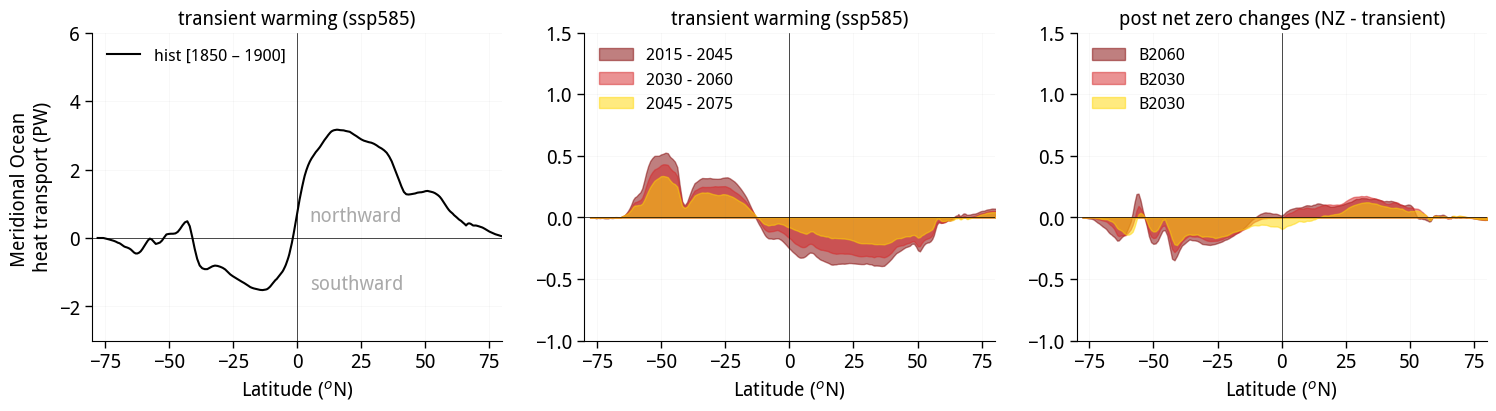

In [29]:
plt.figure(figsize=(18,4))

plt.subplot(131)
xdata = oht_pi.lat.to_numpy()

plt.plot(xdata, oht_pi.quantile(0.5, 'model')/1e15, color='k', label='hist [1850 – 1900]')

plt.ylabel('Meridional Ocean \nheat transport (PW)')
plt.xlabel('Latitude ($^{o}$N)')
# plot_decorator()
plt.axhline(0.0, lw=0.5, color='k')
plt.axvline(0.0, lw=0.5, color='k')
# plt.axvline(-30.0, lw=0.5, color='k', ls='--', alpha=0.2)
# plt.axvline(30.0, lw=0.5, color='k', ls='--', alpha=0.2)
# sns.despine(left=True, right=True)
# plt.grid(alpha=0.05)
plot_decorator()
plt.xlim(-80, 80)
plt.ylim(-3, 6)
plt.text(5, 0.5, 'northward', size=14, color='darkgray')
plt.text(5, -1.5, 'southward', size=14, color='darkgray')
plt.title('transient warming (ssp585)', fontsize=14)
plt.legend(frameon=False, loc='upper left', fontsize=12)


plt.subplot(132)
xdata = oht_pi.lat.to_numpy()

# plt.fill_between(xdata, oht_pi.quantile(0.1, 'model')/1e15, oht_pi.quantile(0.9, 'model')/1e15, color='k', alpha=0.2)

# plt.plot(xdata, oht_trans_2030.quantile(0.5, 'model')/1e15, color='gold')
# plt.fill_between(xdata, oht_trans_2030.quantile(0.1, 'model')/1e15, oht_trans_2030.quantile(0.9, 'model')/1e15, color='gold', alpha=0.2)

# plt.plot(xdata, oht_trans_2045.quantile(0.5, 'model')/1e15, color='tab:red')

# plt.plot(xdata, oht_trans_2060.quantile(0.5, 'model')/1e15, color='maroon')

plt.fill_between(xdata, 0, (oht_trans_2060.quantile(0.5, 'model') - oht_pi.quantile(0.5, 'model'))/1e15, color='maroon', alpha=0.5, label='2015 - 2045')
plt.fill_between(xdata, 0, (oht_trans_2045.quantile(0.5, 'model') - oht_pi.quantile(0.5, 'model'))/1e15, color='tab:red', alpha=0.5, label='2030 - 2060')
plt.fill_between(xdata, 0, (oht_trans_2030.quantile(0.5, 'model') - oht_pi.quantile(0.5, 'model'))/1e15, color='gold', alpha=0.5, label='2045 - 2075')


# plt.ylabel('Meridional Ocean \nheat transport (PW)')
plt.xlabel('Latitude ($^{o}$N)')
# plot_decorator()
plt.axhline(0.0, lw=0.5, color='k')
plt.axvline(0.0, lw=0.5, color='k')
# plt.axvline(-30.0, lw=0.5, color='k', ls='--', alpha=0.2)
# plt.axvline(30.0, lw=0.5, color='k', ls='--', alpha=0.2)
# sns.despine(left=True, right=True)
# plt.grid(alpha=0.05)
plot_decorator()
plt.xlim(-80, 80)
plt.ylim(-1.0, 1.5)
# plt.text(5, 0.5, 'northward', size=14, color='darkgray')
# plt.text(5, -1.5, 'southward', size=14, color='darkgray')
plt.title('transient warming (ssp585)', fontsize=14)
plt.legend(frameon=False, loc='upper left', fontsize=12)


# ###
# plt.subplot(132)
# xdata = oht_pi.lat.to_numpy()

# plt.plot(xdata, oht_pi.quantile(0.5, 'model')/1e15, color='k', label='hist [1850 – 1900]')
# # plt.fill_between(xdata, oht_pi.quantile(0.1, 'model')/1e15, oht_pi.quantile(0.9, 'model')/1e15, color='k', alpha=0.2)

# # plt.plot(xdata, oht_stable_2030.quantile(0.5, 'model')/1e15, color='gold')
# # plt.fill_between(xdata, oht_stable_2030.quantile(0.1, 'model')/1e15, oht_stable_2030.quantile(0.9, 'model')/1e15, color='gold', alpha=0.2)

# # plt.plot(xdata, oht_stable_2045.quantile(0.5, 'model')/1e15, color='tab:red')

# # plt.plot(xdata, oht_stable_2060.quantile(0.5, 'model')/1e15, color='maroon')

# plt.fill_between(xdata, 0, (oht_stable_2060.quantile(0.5, 'model') - oht_pi.quantile(0.5, 'model'))/1e15, color='maroon', alpha=0.5, label='NZ $\Delta$ [B2060]')
# plt.fill_between(xdata, 0, (oht_stable_2045.quantile(0.5, 'model') - oht_pi.quantile(0.5, 'model'))/1e15, color='tab:red', alpha=0.5, label='NZ $\Delta$ [B2045]')
# plt.fill_between(xdata, 0, (oht_stable_2030.quantile(0.5, 'model') - oht_pi.quantile(0.5, 'model'))/1e15, color='gold', alpha=0.5, label='NZ $\Delta$ [B2030]')


# # plt.ylabel('Meridional Ocean \nheat transport (PW)')
# plt.xlabel('Latitude ($^{o}$N)')
# # plot_decorator()
# plt.axhline(0.0, lw=0.5, color='k')
# plt.axvline(0.0, lw=0.5, color='k')
# # sns.despine(left=True, right=True)
# # plt.grid(alpha=0.05)
# plot_decorator()
# plt.xlim(-80, 80)
# plt.ylim(-3, 6)
# plt.text(5, 0.5, 'northward', size=14, color='darkgray')
# plt.text(5, -1.5, 'southward', size=14, color='darkgray')
# plt.title('net zero (NZ)', fontsize=14)
# plt.legend(frameon=False, loc='upper left', fontsize=12)


###
plt.subplot(133)
xdata = oht_pi.lat.to_numpy()

# plt.fill_between(xdata, oht_pi.quantile(0.1, 'model')/1e15, oht_pi.quantile(0.9, 'model')/1e15, color='k', alpha=0.2)

# plt.plot(xdata, oht_stable_2030.quantile(0.5, 'model')/1e15, color='gold')
# plt.fill_between(xdata, oht_stable_2030.quantile(0.1, 'model')/1e15, oht_stable_2030.quantile(0.9, 'model')/1e15, color='gold', alpha=0.2)

# plt.plot(xdata, oht_stable_2045.quantile(0.5, 'model')/1e15, color='tab:red')

# plt.plot(xdata, oht_stable_2060.quantile(0.5, 'model')/1e15, color='maroon')

plt.fill_between(xdata, 0, (oht_stable_2060.quantile(0.5, 'model') - oht_trans_2060.quantile(0.5, 'model'))/1e15, color='maroon', alpha=0.5, label='B2060')
plt.fill_between(xdata, 0, (oht_stable_2045.quantile(0.5, 'model') - oht_trans_2045.quantile(0.5, 'model'))/1e15, color='tab:red', alpha=0.5, label='B2030')
plt.fill_between(xdata, 0, (oht_stable_2030.quantile(0.5, 'model') - oht_trans_2030.quantile(0.5, 'model'))/1e15, color='gold', alpha=0.5, label='B2030')


# plt.ylabel('Meridional Ocean \nheat transport (PW)')
plt.xlabel('Latitude ($^{o}$N)')
# plot_decorator()
plt.axhline(0.0, lw=0.5, color='k')
plt.axvline(0.0, lw=0.5, color='k')
# sns.despine(left=True, right=True)
# plt.grid(alpha=0.05)
plot_decorator()
plt.xlim(-80, 80)
plt.ylim(-1.0, 1.5)
# plt.text(5, 0.5, 'northward', size=14, color='darkgray')
# plt.text(5, -1.0, 'southward', size=14, color='darkgray')
plt.title('post net zero changes (NZ - transient)', fontsize=14)
plt.legend(frameon=False, loc='upper left', fontsize=12)

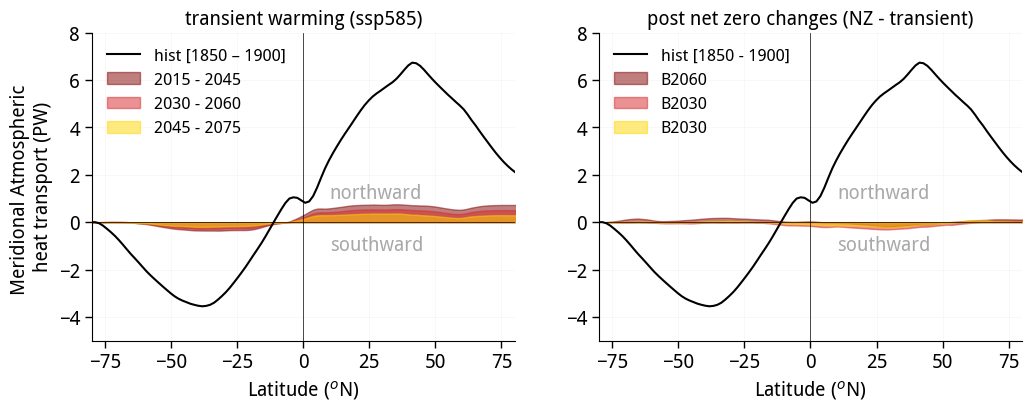

In [ ]:
plt.figure(figsize=(12,4))

plt.subplot(121)
xdata = aht_pi.lat.to_numpy()

plt.plot(xdata, aht_pi.quantile(0.5, 'model'), color='k', label='hist [1850 – 1900]')
# plt.fill_between(xdata, aht_pi.quantile(0.1, 'model'), aht_pi.quantile(0.9, 'model'), color='k', alpha=0.2)

# plt.plot(xdata, aht_trans_2030.quantile(0.5, 'model'), color='gold')
# plt.fill_between(xdata, aht_trans_2030.quantile(0.1, 'model'), aht_trans_2030.quantile(0.9, 'model'), color='gold', alpha=0.2)

# plt.plot(xdata, aht_trans_2045.quantile(0.5, 'model'), color='tab:red')

# plt.plot(xdata, aht_trans_2060.quantile(0.5, 'model'), color='maroon')

plt.fill_between(xdata, 0, (aht_trans_2060.quantile(0.5, 'model') - aht_pi.quantile(0.5, 'model')), color='maroon', alpha=0.5, label='2015 - 2045')
plt.fill_between(xdata, 0, (aht_trans_2045.quantile(0.5, 'model') - aht_pi.quantile(0.5, 'model')), color='tab:red', alpha=0.5, label='2030 - 2060')
plt.fill_between(xdata, 0, (aht_trans_2030.quantile(0.5, 'model') - aht_pi.quantile(0.5, 'model')), color='gold', alpha=0.5, label='2045 - 2075')


plt.ylabel('Meridional Atmospheric \nheat transport (PW)')
plt.xlabel('Latitude ($^{o}$N)')
# plot_decorator()
plt.axhline(0.0, lw=0.5, color='k')
plt.axvline(0.0, lw=0.5, color='k')
# plt.axvline(-30.0, lw=0.5, color='k', ls='--', alpha=0.2)
# plt.axvline(30.0, lw=0.5, color='k', ls='--', alpha=0.2)
# sns.despine(left=True, right=True)
# plt.grid(alpha=0.05)
plot_decorator()
plt.xlim(-80, 80)
plt.ylim(-5, 8)
plt.text(10, 1.0, 'northward', size=14, color='darkgray')
plt.text(10, -1.2, 'southward', size=14, color='darkgray')
plt.title('transient warming (ssp585)', fontsize=14)
plt.legend(frameon=False, loc='upper left', fontsize=12)


# ###
# plt.subplot(132)
# xdata = aht_pi.lat.to_numpy()

# plt.plot(xdata, aht_pi.quantile(0.5, 'model'), color='k', label='hist [1850 – 1900]')
# # plt.fill_between(xdata, aht_pi.quantile(0.1, 'model'), aht_pi.quantile(0.9, 'model'), color='k', alpha=0.2)

# # plt.plot(xdata, aht_stable_2030.quantile(0.5, 'model'), color='gold')
# # plt.fill_between(xdata, aht_stable_2030.quantile(0.1, 'model'), aht_stable_2030.quantile(0.9, 'model'), color='gold', alpha=0.2)

# # plt.plot(xdata, aht_stable_2045.quantile(0.5, 'model'), color='tab:red')

# # plt.plot(xdata, aht_stable_2060.quantile(0.5, 'model'), color='maroon')

# plt.fill_between(xdata, 0, (aht_stable_2060.quantile(0.5, 'model') - aht_pi.quantile(0.5, 'model')), color='maroon', alpha=0.5, label='NZ $\Delta$ [B2060]')
# plt.fill_between(xdata, 0, (aht_stable_2045.quantile(0.5, 'model') - aht_pi.quantile(0.5, 'model')), color='tab:red', alpha=0.5, label='NZ $\Delta$ [B2045]')
# plt.fill_between(xdata, 0, (aht_stable_2030.quantile(0.5, 'model') - aht_pi.quantile(0.5, 'model')), color='gold', alpha=0.5, label='NZ $\Delta$ [B2030]')


# # plt.ylabel('Meridional Atmospheric \nheat transport (PW)')
# plt.xlabel('Latitude ($^{o}$N)')
# # plot_decorator()
# plt.axhline(0.0, lw=0.5, color='k')
# plt.axvline(0.0, lw=0.5, color='k')
# # sns.despine(left=True, right=True)
# # plt.grid(alpha=0.05)
# plot_decorator()
# plt.xlim(-80, 80)
# plt.ylim(-5, 8)
# plt.text(10, 1.0, 'northward', size=14, color='darkgray')
# plt.text(10, -1.2, 'southward', size=14, color='darkgray')
# plt.title('net zero (NZ)', fontsize=14)
# plt.legend(frameon=False, loc='upper left', fontsize=12)


###
plt.subplot(122)
xdata = aht_pi.lat.to_numpy()

plt.plot(xdata, aht_pi.quantile(0.5, 'model'), color='k', label='hist [1850 - 1900]')
# plt.fill_between(xdata, aht_pi.quantile(0.1, 'model'), aht_pi.quantile(0.9, 'model'), color='k', alpha=0.2)

# plt.plot(xdata, aht_stable_2030.quantile(0.5, 'model'), color='gold')
# plt.fill_between(xdata, aht_stable_2030.quantile(0.1, 'model'), aht_stable_2030.quantile(0.9, 'model'), color='gold', alpha=0.2)

# plt.plot(xdata, aht_stable_2045.quantile(0.5, 'model'), color='tab:red')

# plt.plot(xdata, aht_stable_2060.quantile(0.5, 'model'), color='maroon')

plt.fill_between(xdata, 0, (aht_stable_2060.quantile(0.5, 'model') - aht_trans_2060.quantile(0.5, 'model')), color='maroon', alpha=0.5, label='B2060')
plt.fill_between(xdata, 0, (aht_stable_2045.quantile(0.5, 'model') - aht_trans_2045.quantile(0.5, 'model')), color='tab:red', alpha=0.5, label='B2030')
plt.fill_between(xdata, 0, (aht_stable_2030.quantile(0.5, 'model') - aht_trans_2030.quantile(0.5, 'model')), color='gold', alpha=0.5, label='B2030')


# plt.ylabel('Meridional Atmospheric \nheat transport (PW)')
plt.xlabel('Latitude ($^{o}$N)')
# plot_decorator()
plt.axhline(0.0, lw=0.5, color='k')
plt.axvline(0.0, lw=0.5, color='k')
# sns.despine(left=True, right=True)
# plt.grid(alpha=0.05)
plot_decorator()
plt.xlim(-80, 80)
plt.ylim(-5, 8)
plt.text(10, 1.0, 'northward', size=14, color='darkgray')
plt.text(10, -1.2, 'southward', size=14, color='darkgray')
plt.title('post net zero changes (NZ - transient)', fontsize=14)
plt.legend(frameon=False, loc='upper left', fontsize=12)

###  changes in toa radiation and surface fluxes (postive into ocean)

In [ ]:
rtoa_trans_anom = funcs.calc_anom(rtoa_trans, rtoa_trans.sel(time = slice('1960', '1990')))
fsfc_trans_anom = funcs.calc_anom(fsfc_trans, fsfc_trans.sel(time = slice('1960', '1990')))

In [ ]:
rtoa_stable_anom = funcs.calc_anom_annual(rtoa_stable, rtoa_trans.sel(model = 'ACCESS-ESM1-5_r10i1p1f', time = slice('1960', '1990')))
fsfc_stable_anom = funcs.calc_anom_annual(fsfc_stable, fsfc_trans.sel(model = 'ACCESS-ESM1-5_r10i1p1f', time = slice('1960', '1990')))

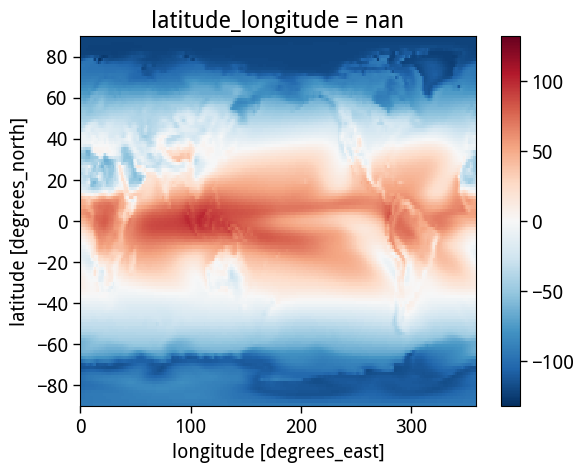

In [ ]:
rtoa_trans.sel(time = slice('1850', '1900')).mean(('time', 'model')).plot()

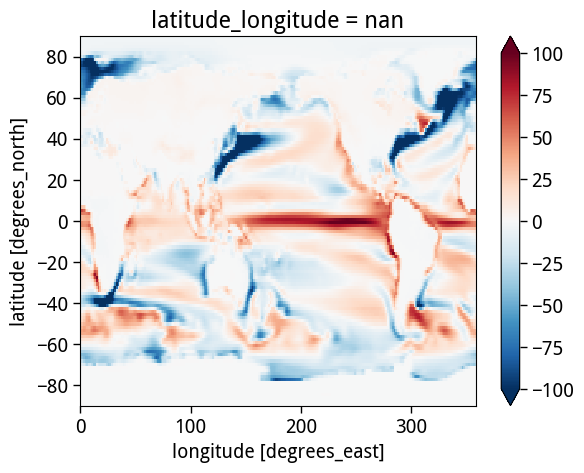

In [ ]:
fsfc_trans.sel(time = slice('1850', '1900')).mean(('time', 'model')).plot(vmin=-100)

In [36]:
# plot_list = [
#     (rtoa_trans.rtoa/100).sel(lat = slice(-30, 30), lon = slice(100, 300)).sel(time = slice('2045', '2075')).mean(('model', 'time')),
#     (rtoa_trans.rtoa/100).sel(lat = slice(-30, 30), lon = slice(100, 300)).sel(time = slice('2030', '2060')).mean(('model', 'time')),
#     (rtoa_trans.rtoa/100).sel(lat = slice(-30, 30), lon = slice(100, 300)).sel(time = slice('2015', '2045')).mean(('model', 'time')),
# ]

plot_list = [
    (rtoa_trans_anom).sel(lat = slice(-90, 90)).sel(time = slice('2045', '2075')).mean(('model', 'time')),
    (rtoa_trans_anom).sel(lat = slice(-90, 90)).sel(time = slice('2030', '2060')).mean(('model', 'time')),
    (rtoa_trans_anom).sel(lat = slice(-90, 90)).sel(time = slice('2015', '2045')).mean(('model', 'time')),
]

In [37]:
xx, yy = np.meshgrid(plot_list[0].lon, plot_list[0].lat)

In [38]:
contour_data = [
    (rtoa_trans).sel(lat = slice(-90, 90)).sel(time = slice('1850', '1900')).mean(('model', 'time')),
    (rtoa_trans).sel(lat = slice(-90, 90)).sel(time = slice('1850', '1900')).mean(('model', 'time')),
    (rtoa_trans).sel(lat = slice(-90, 90)).sel(time = slice('1850', '1900')).mean(('model', 'time')),
]

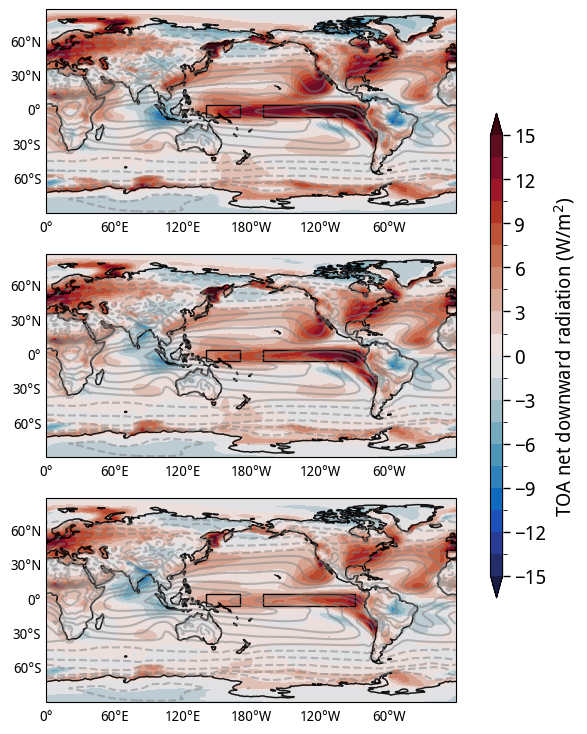

In [41]:
plot_maps(xx, yy, plot_list, ['']*3, ['']*3, cmap=cmocean.cm.balance, levels = np.linspace(-15, 15, 21), pval = [], draw_winds=False, u_wnd=[], v_wnd=[], wind_scale=0.09, draw_contour=True, contour_data=contour_data, contour_levels=np.linspace(-90, 90, 11), contour_colors='tab:gray',
            nrows=3, ncols=1, figsize=(9,9), land_mask_list = [], add_patch=True, add_patch_extra=False, hatch_type = 'insig', proj=ccrs.PlateCarree(central_longitude=180), 
            cbar_kwargs=dict(orientation='vertical', label='TOA net downward radiation (W/m$^{2}$)', aspect=40, shrink=0.7, pad=0.05), draw_labels=True, draw_colorbar=True, auto_aspect=False)


In [42]:
def additional_sampling_stabilisation(da, initiator=100, spacer=30):
    i = initiator
    da_list = []
    while i <= 1000 - spacer:
        sample_da = da.isel(time = slice(i,i+spacer)).mean('time')
        da_list.append(sample_da)
        i += spacer
    print('Done')
    out_da = xr.concat(da_list, dim=np.arange(0, (1000 - initiator)/spacer, 1))
    if 'model' in out_da.coords:
        return out_da.drop('model').rename(dict(concat_dim='model'))
    else:
        return out_da.rename(dict(concat_dim='model'))


def additional_sampling_stabilisation_nomeans(da, initiator=100, spacer=30):
    i = initiator
    da_list = []
    while i <= 1000 - spacer:
        sample_da = da.isel(time = slice(i,i+spacer))
        da_list.append(sample_da)
        i += spacer
    print('Done')
    out_da = xr.concat(da_list, dim=np.arange(0, (1000 - initiator)/spacer, 1))
    if 'model' in out_da.coords:
        return out_da.drop('model').rename(dict(concat_dim='model'))
    else:
        return out_da.rename(dict(concat_dim='model'))


In [44]:
stable_plot_list = [
    additional_sampling_stabilisation((rtoa_stable_anom).sel(model = '2060').sel(lat = slice(-90, 90)).sel(time = slice('2060', '3060'))).mean(('model')),
    additional_sampling_stabilisation((rtoa_stable_anom).sel(model = '2045').sel(lat = slice(-90, 90)).sel(time = slice('2045', '3045'))).mean(('model')),
    additional_sampling_stabilisation((rtoa_stable_anom).sel(model = '2030').sel(lat = slice(-90, 90)).sel(time = slice('2030', '3030'))).mean(('model')),
]

Done
Done
Done


In [51]:
pval_list = [
    funcs.mannwhitneyu3d((rtoa_trans_anom).sel(lat = slice(-90, 90), time = slice('2045', '2075')).mean(('time')), additional_sampling_stabilisation((rtoa_stable_anom).sel(model = '2060').sel(lat = slice(-90, 90)).sel(time = slice('2060', '3060'))), dim='model'),
    funcs.mannwhitneyu3d((rtoa_trans_anom).sel(lat = slice(-90, 90), time = slice('2030', '2060')).mean(('time')), additional_sampling_stabilisation((rtoa_stable_anom).sel(model = '2045').sel(lat = slice(-90, 90)).sel(time = slice('2045', '3045'))), dim='model'),
    funcs.mannwhitneyu3d((rtoa_trans_anom).sel(lat = slice(-90, 90), time = slice('2015', '2045')).mean(('time')), additional_sampling_stabilisation((rtoa_stable_anom).sel(model = '2030').sel(lat = slice(-90, 90)).sel(time = slice('2030', '3030'))), dim='model'),
]

Done
Done
Done


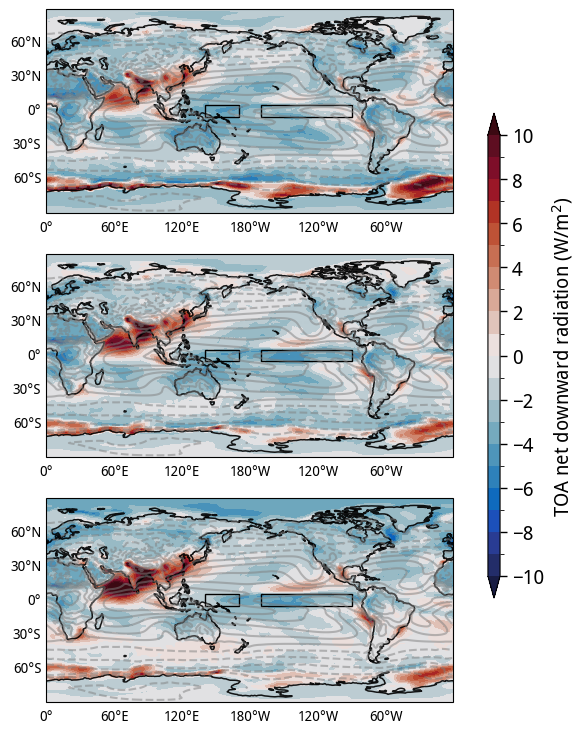

In [54]:
plot_maps(xx, yy, np.array(stable_plot_list) - np.array(plot_list), ['']*3, ['']*3, cmap=cmocean.cm.balance, levels = np.linspace(-10, 10, 21), pval = pval_list, draw_winds=False, u_wnd=[], v_wnd=[], wind_scale=0.09, draw_contour=True, contour_data=contour_data, contour_levels=np.linspace(-90, 90, 11), contour_colors='tab:gray',
            nrows=3, ncols=1, figsize=(9,9), land_mask_list = [], add_patch=True, add_patch_extra=False, hatch_type = 'sig', proj=ccrs.PlateCarree(central_longitude=180), 
            cbar_kwargs=dict(orientation='vertical', label='TOA net downward radiation (W/m$^{2}$)', aspect=40, shrink=0.7, pad=0.05), draw_labels=True, draw_colorbar=True, auto_aspect=False)


In [55]:
# plot_list = [
#     (fsfc_trans.fsfc/100).sel(lat = slice(-30, 30), lon = slice(100, 300)).sel(time = slice('2045', '2075')).mean(('model', 'time')),
#     (fsfc_trans.fsfc/100).sel(lat = slice(-30, 30), lon = slice(100, 300)).sel(time = slice('2030', '2060')).mean(('model', 'time')),
#     (fsfc_trans.fsfc/100).sel(lat = slice(-30, 30), lon = slice(100, 300)).sel(time = slice('2015', '2045')).mean(('model', 'time')),
# ]

plot_list = [
    (fsfc_trans_anom).sel(lat = slice(-90, 90)).sel(time = slice('2045', '2075')).mean(('model', 'time')),
    (fsfc_trans_anom).sel(lat = slice(-90, 90)).sel(time = slice('2030', '2060')).mean(('model', 'time')),
    (fsfc_trans_anom).sel(lat = slice(-90, 90)).sel(time = slice('2015', '2045')).mean(('model', 'time')),
]

In [56]:
xx, yy = np.meshgrid(plot_list[0].lon, plot_list[0].lat)

In [57]:
contour_data = [
    (fsfc_trans).sel(lat = slice(-90, 90)).sel(time = slice('1850', '1900')).mean(('model', 'time')),
    (fsfc_trans).sel(lat = slice(-90, 90)).sel(time = slice('1850', '1900')).mean(('model', 'time')),
    (fsfc_trans).sel(lat = slice(-90, 90)).sel(time = slice('1850', '1900')).mean(('model', 'time')),
]

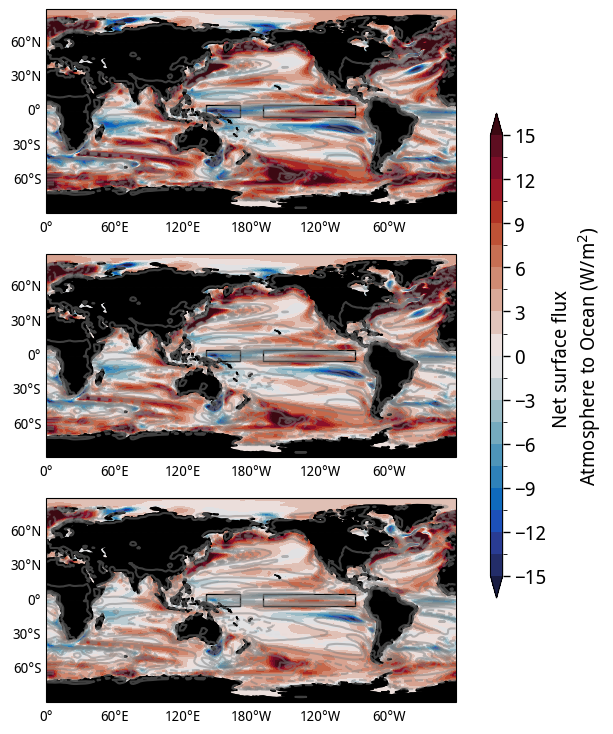

In [60]:
plot_maps(xx, yy, plot_list, ['']*3, ['']*3, cmap=cmocean.cm.balance, levels = np.linspace(-15, 15, 21), pval = [], draw_winds=False, u_wnd=[], v_wnd=[], wind_scale=0.09, draw_contour=True, contour_data=contour_data, contour_levels=np.linspace(-90, 90, 11), contour_colors='tab:gray',
            nrows=3, ncols=1, figsize=(9,9), land_mask_list = np.arange(0, 3, 1), add_patch=True, add_patch_extra=False, hatch_type = 'insig', proj=ccrs.PlateCarree(central_longitude=180), 
            cbar_kwargs=dict(orientation='vertical', label='Net surface flux \nAtmosphere to Ocean (W/m$^{2}$)', aspect=40, shrink=0.7, pad=0.05), draw_labels=True, draw_colorbar=True, auto_aspect=False)


In [59]:
stable_plot_list = [
    additional_sampling_stabilisation((fsfc_stable_anom).sel(model = '2060').sel(lat = slice(-90, 90)).sel(time = slice('2060', '3060'))).mean(('model')),
    additional_sampling_stabilisation((fsfc_stable_anom).sel(model = '2045').sel(lat = slice(-90, 90)).sel(time = slice('2045', '3045'))).mean(('model')),
    additional_sampling_stabilisation((fsfc_stable_anom).sel(model = '2030').sel(lat = slice(-90, 90)).sel(time = slice('2030', '3030'))).mean(('model')),
]

Done
Done
Done


In [61]:
pval_list = [
    funcs.mannwhitneyu3d((fsfc_trans_anom).sel(lat = slice(-90, 90), time = slice('2045', '2075')).mean(('time')), additional_sampling_stabilisation((fsfc_stable_anom).sel(model = '2060').sel(lat = slice(-90, 90)).sel(time = slice('2060', '3060'))), dim='model'),
    funcs.mannwhitneyu3d((fsfc_trans_anom).sel(lat = slice(-90, 90), time = slice('2030', '2060')).mean(('time')), additional_sampling_stabilisation((fsfc_stable_anom).sel(model = '2045').sel(lat = slice(-90, 90)).sel(time = slice('2045', '3045'))), dim='model'),
    funcs.mannwhitneyu3d((fsfc_trans_anom).sel(lat = slice(-90, 90), time = slice('2015', '2045')).mean(('time')), additional_sampling_stabilisation((fsfc_stable_anom).sel(model = '2030').sel(lat = slice(-90, 90)).sel(time = slice('2030', '3030'))), dim='model'),
]

Done
Done
Done


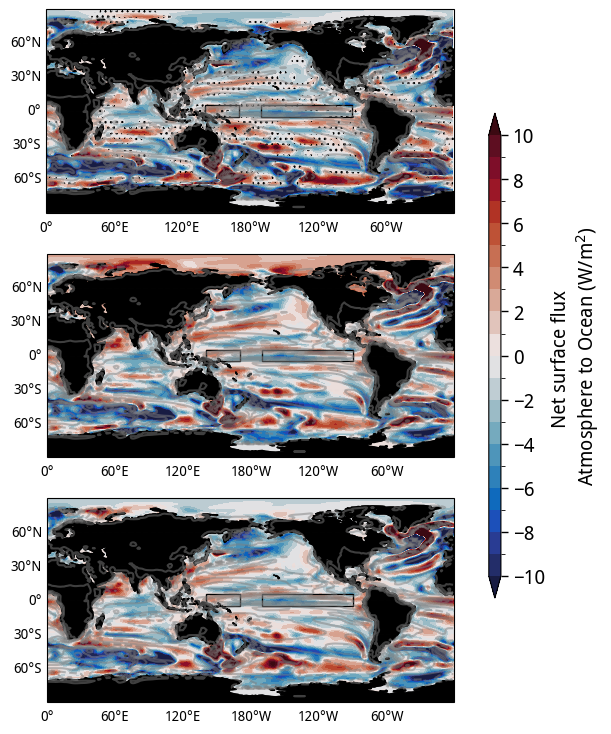

In [63]:
plot_maps(xx, yy, np.array(stable_plot_list) - np.array(plot_list), ['']*3, ['']*3, cmap=cmocean.cm.balance, levels = np.linspace(-10, 10, 21), pval = pval_list, draw_winds=False, u_wnd=[], v_wnd=[], wind_scale=0.09, draw_contour=True, contour_data=contour_data, contour_levels=np.linspace(-90, 90, 11), contour_colors='tab:gray',
            nrows=3, ncols=1, figsize=(9,9), land_mask_list = np.arange(0, 3, 1), add_patch=True, add_patch_extra=False, hatch_type = 'insig', proj=ccrs.PlateCarree(central_longitude=180), 
            cbar_kwargs=dict(orientation='vertical', label='Net surface flux \nAtmosphere to Ocean (W/m$^{2}$)', aspect=40, shrink=0.7, pad=0.05), draw_labels=True, draw_colorbar=True, auto_aspect=False)
